In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import glob
import cv2
import re
from tqdm import tqdm
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt
import matplotlib
import os
#import h5py
import matplotlib.cm as cm

In [2]:
#Change directories 
exp_name = '20241107_1'

#curr_dir='/run/user/1000/gvfs/smb-share:server=bucket.oist.jp,share=bucket/ReiterU/Ants/basler/20241107_1/20241107_1_first_hour/data/'
curr_dir='/Volumes/ReiterU/Ants/basler/' + exp_name + '/' + exp_name +'_first_hour/data/'


output_folder_path = '/Volumes/ReiterU/Anouk/basler_data/' + exp_name + '/'
#output_folder_path = '/run/user/1000/gvfs/smb-share:server=bucket.oist.jp,share=bucket/ReiterU//Anouk/basler_data/20241107_1/'


hmats_dir = '/Volumes/ReiterU/Ants/basler/cameraArray_calib/2024-11-03_2/frame_1/bundle_adjustment_paras.mat'
#hmats_dir = '/run/user/1000/gvfs/smb-share:server=bucket.oist.jp,share=bucket/ReiterU/Ants/basler/cameraArray_calib/2024-11-03_2/frame_1/bundle_adjustment_paras.mat'
output_file_name = exp_name + '_sleap_panorama_frame.pkl'
col_1, col_2 = 9,11

In [3]:
###########################Functions ##########################################

def get_Hmats(dir):

    #how to load up parameters of the mapping
    mat = scipy.io.loadmat(dir)  
    paras = np.squeeze(mat['paras'])
    
    im_n = 25# set this to the number of images or the appropriate value
    H_pair = [[np.eye(3) if i == j else None for j in range(im_n)] for i in range(im_n)]
    for ii in range(1, im_n):
        currParams = paras[(4*(ii-1)):(4*ii)]
    
        S = np.array([[currParams[0], currParams[1], currParams[2]],
                      [currParams[1], currParams[0], currParams[3]]])
        H_pair[0][ii] = np.vstack([S, [0, 0, 1]])
        H_pair[ii][0] = np.linalg.inv(H_pair[0][ii])
    
    for i in range(1, im_n-1):
        for j in range(i+1, im_n):
            H_pair[i][j] = np.dot(H_pair[0][j], H_pair[i][0])
            H_pair[j][i] = np.linalg.inv(H_pair[i][j])
    
    H_mats = H_pair[12]
    H_mats_flipped = np.flip(H_mats, axis=0)
    return H_mats_flipped
    
def map_points(points, H):
    
    homogeneous_points = np.hstack([points, np.ones((points.shape[0], 1))])
    transformed_points_homogeneous = homogeneous_points @ H.T  # Matrix multiplication
    transformed_points = transformed_points_homogeneous[:, :2] / transformed_points_homogeneous[:, [2]]

    return transformed_points

def map_points_inv(points, H):
    
    transformed_points = np.hstack([points, np.ones((points.shape[0], 1))])
    original_points_homogeneous = transformed_points @ np.linalg.inv(H).T  # Matrix multiplication
    original_points = original_points_homogeneous[:, :2] / original_points_homogeneous[:, [2]]

    return original_points


def convert_to_pickle(folder_path, pickle_name, df_to_convert): 
    #Create a new folder with the combined files in the desired directory 
    folder_name = folder_path.split('/')[-2]
    if not os.path.exists(folder_path):
        # If the folder does not exist, create it
        os.makedirs(folder_path)
        print(f"Folder '{folder_name}' created in '{folder_path}'.")
    else:
        print(f"Folder '{folder_name}' already exists in '{folder_path}'.")

    df_to_convert.to_pickle(folder_path +  pickle_name )
    
    return

def check_calibration(xy_array):
    fig, ax = plt.subplots()
    ax.invert_yaxis()
    cmap = plt.colormaps['viridis']
    custom_cmap = cm.get_cmap(cmap, 25)
    for curr_cam in range(0,25):
        curr_H=H_mats[curr_cam]
        color = custom_cmap(curr_cam / (25 - 1))
        mapped_points=map_points(xy_array,curr_H)
        plt.plot(mapped_points[0:10000,0],mapped_points[0:10000,1],color=color)  
        plt.text(mapped_points[-1,0],mapped_points[-1,1], str(curr_cam))


def combine_sleap(H_mats, curr_dir):
    # Retrieve all CSV files in the current_directory if they are not frame counts 
    csv_files = glob.glob(curr_dir + '*.csv')
    filtered_files = [s for s in csv_files if 'frame_counts' not in s]

    # Extract sleap files and convert to DataFrame 
    df = pd.read_csv(filtered_files[0])
    df = df.drop(['Score_node'], axis=1)
    total_df = pd.DataFrame(columns=df.columns)

    # For each camera, map the points to the panorama using Hmats and load the new coordinates in a new df
    max_instance = 0
    for csv in filtered_files:
        print("File:", csv)
        df = pd.read_csv(csv)
        df = df.drop(['Score_node'], axis=1)

        # Reset instance counter for each new frame
        df['Instance'] = df.groupby('Frame').cumcount() + 1

        # Add the camera number column
        filename = csv.split('_')
        curr_cam = int(filename[6][-2:]) - 1  # Adjust camera index
        df['Cam'] = curr_cam

        # Map points to the panorama
        curr_H = H_mats[curr_cam]
        xy_array = df[['X', 'Y']].to_numpy()
        mapped_points = map_points(xy_array, curr_H)
        df['X'] = mapped_points[:, 0]
        df['Y'] = mapped_points[:, 1]

        total_df = pd.concat([total_df, df], ignore_index=True)

    return total_df


In [4]:
#Get the homography matrix 
H_mats=get_Hmats(hmats_dir)


/var/folders/g_/4b9x69ss41l4t1mtqrg5qqjc0000gp/T/ipykernel_32623/538823919.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  custom_cmap = cm.get_cmap(cmap, 25)


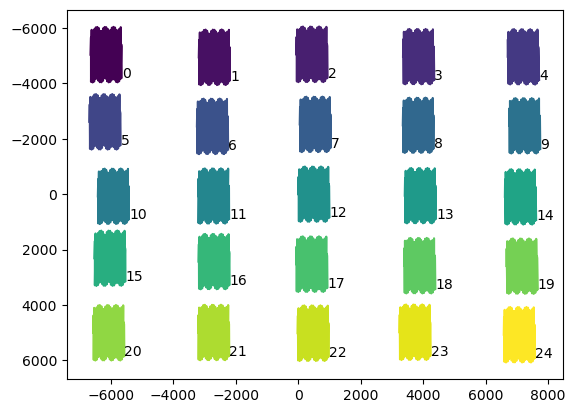

In [5]:
#Check the order of cameras 
x = np.linspace(0,1000,100)
y = 1000*np.sin(x)
xy_array = np.array([x.T, y.T])

check_calibration(xy_array.T)

In [6]:
#Combine tracks from all cameras into a single set 
sleap_tracks_combined = combine_sleap(H_mats, curr_dir)

File: /Volumes/ReiterU/Ants/basler/20241107_1/20241107_1_first_hour/data/cam1_2024-11-06-23-48-48_cam02_first_hour_000.csv


/var/folders/g_/4b9x69ss41l4t1mtqrg5qqjc0000gp/T/ipykernel_32623/538823919.py:104: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  total_df = pd.concat([total_df, df], ignore_index=True)


File: /Volumes/ReiterU/Ants/basler/20241107_1/20241107_1_first_hour/data/cam1_2024-11-06-23-49-08_cam10_first_hour_000.csv
File: /Volumes/ReiterU/Ants/basler/20241107_1/20241107_1_first_hour/data/cam7_2024-11-06-23-48-48_cam08_first_hour_000.csv
File: /Volumes/ReiterU/Ants/basler/20241107_1/20241107_1_first_hour/data/cam0_2024-11-06-23-49-08_cam09_first_hour_000.csv
File: /Volumes/ReiterU/Ants/basler/20241107_1/20241107_1_first_hour/data/cam5_2024-11-06-23-49-08_cam14_first_hour_000.csv
File: /Volumes/ReiterU/Ants/basler/20241107_1/20241107_1_first_hour/data/cam2_2024-11-06-23-48-27_cam20_first_hour_000.csv
File: /Volumes/ReiterU/Ants/basler/20241107_1/20241107_1_first_hour/data/cam0_2024-11-06-23-48-28_cam18_first_hour_000.csv
File: /Volumes/ReiterU/Ants/basler/20241107_1/20241107_1_first_hour/data/cam2_2024-11-06-23-48-48_cam03_first_hour_000.csv
File: /Volumes/ReiterU/Ants/basler/20241107_1/20241107_1_first_hour/data/cam8_2024-11-06-23-49-09_cam17_first_hour_000.csv
File: /Volumes/R

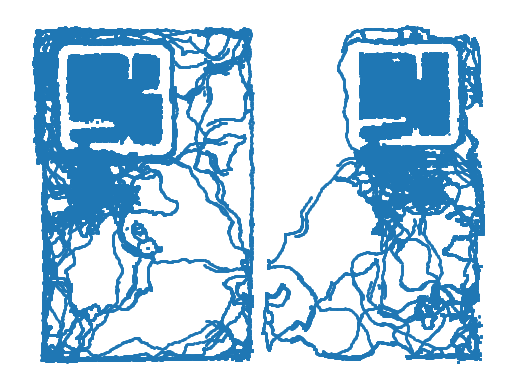

In [7]:
#Check sleap tracks together to verify shapes

fig, ax = plt.subplots()
ax.invert_yaxis()
# Remove x-axis tick labels
#plt.gca().set_xticks([])
#plt.gca().set_yticks([])
plt.plot(sleap_tracks_combined['X'], sleap_tracks_combined['Y'], "o", markersize = 1)
plt.axis('off')
plt.show()


In [8]:
sleap_tracks_combined['Colony_name'] = sleap_tracks_combined['X'].apply(lambda x: col_1 if x < 2000 else col_2)


In [9]:
#Save the panorama frame tracks 
convert_to_pickle(output_folder_path, output_file_name,sleap_tracks_combined)

Folder '20241107_1' already exists in '/Volumes/ReiterU//Anouk/basler_data/20241107_1/'.
